# Lecture pour entrainement pandas


In [1]:

import networkx as nx
from networkx.relabel import relabel_nodes
from importlib import reload
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from model import RandomNetwork, ManualNetwork, TrivialNetwork
from controller import Simulation
from core_periphery import create_core_periphery_network
from scale_free import create_scalefree_network
from scale_free import create_smallworld_network

from sklearn.compose import make_column_transformer

from core_periphery import *

> ## Different mesure for resilience of the network

In [2]:
# Fixer le générateur aléatoire
#np.random.seed(42)

# Reseau core-periphery bizarre
number_bank = 1000
n_core = int(number_bank /2)
n_periphery = number_bank - n_core

In [34]:
#network_manual = TrivialNetwork(5000)
#core_periphery_network = create_core_periphery_network(n_core, n_periphery, p_core=0.85, p_periphery=0.3)
network_random = RandomNetwork(500, 1)

In [35]:
#vector_outside_asset = np.copy(network_manual.get_vector_outside_assets())
#vector_outside_asset = np.copy(core_periphery_network.get_vector_outside_assets())
vector_outside_asset = np.copy(network_random.get_vector_outside_assets())

shock measure vector:  1.0
default count vector  1.0


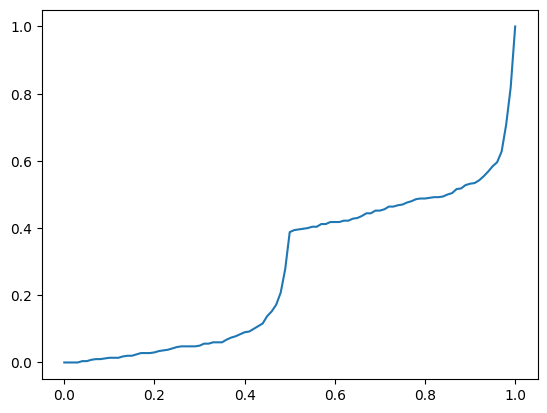

In [36]:


default_count_vector = []
shock_measure_vector = []



shock_vector = np.copy(vector_outside_asset/100)
for k in range(0,101):
    shock_vector = k*vector_outside_asset/100
    #simulation_core_network = Simulation("Eisenberg", network_manual, shock_vector)
    #simulation_core_network = Simulation("Eisenberg", core_periphery_network, shock_vector)
    simulation_core_network = Simulation("Eisenberg",network_random, shock_vector)



    _ , shock_measure, default_count, _ = simulation_core_network.simulate()

    #network_manual.set_vector_outside_assets(vector_outside_asset)
    #core_periphery_network.set_vector_outside_assets(vector_outside_asset)
    network_random.set_vector_outside_assets(vector_outside_asset)




    shock_measure_vector.append(shock_measure)
    default_count_vector.append(default_count)


print("shock measure vector: ",shock_measure_vector[-1])
print("default count vector ",default_count_vector[-1])

plt.plot( shock_measure_vector, default_count_vector)
plt.show()



In [40]:
a = np.array([
    [0, 2],
    [4, 0]
])

du_pay = np.sum(a, axis=1)
on_me_doit = np.sum(a, axis=0)
du_pay, on_me_doit

(array([2, 4]), array([4, 2]))

In [41]:
a = np.array([0, 1, 3])
b = a >= 1
c = np.array([10, 27, 31])
v = np.array([11, 23, 37])

d1 = c[b]/v[b]
d2 = c[~b]/v[~b]
np.concatenate((d1, d2))

array([1.17391304, 0.83783784, 0.90909091])

In [161]:
import scipy.stats as stats
import matplotlib.pyplot as plt

In [183]:
g  = stats.gamma.rvs(a=1, loc=0, scale=100, size=1000)
len(np.linspace(0,101,1000))

1000

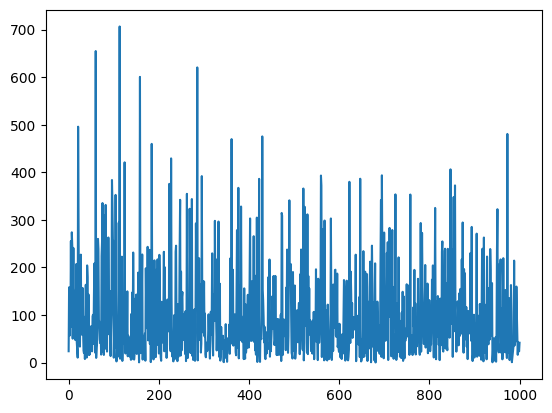

In [184]:
plt.plot(np.linspace(0,1000,1000),g)

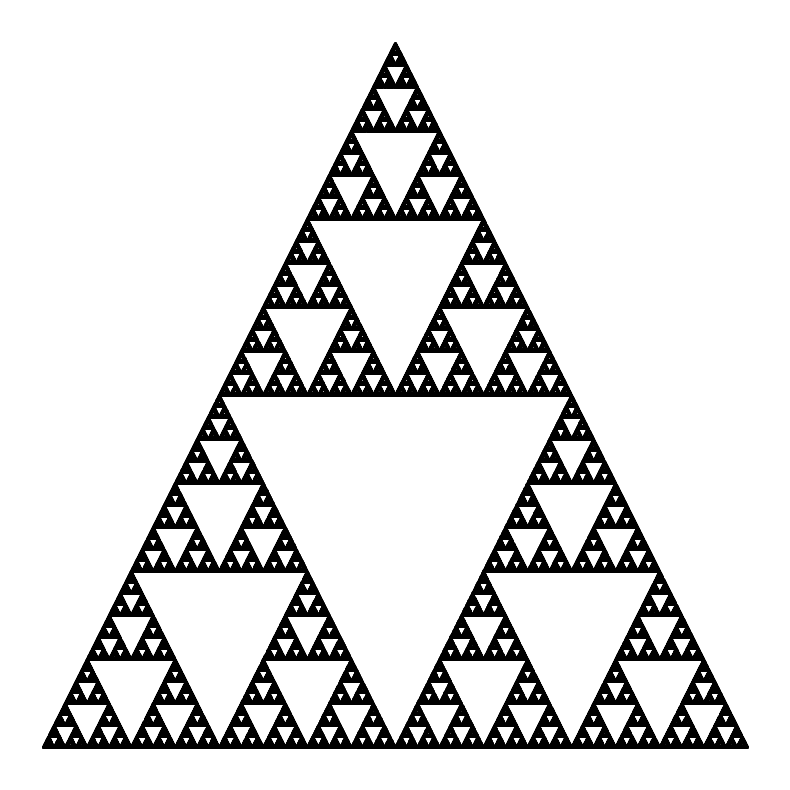

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import random

def sierpinski_ifs(num_points=1000000):
    # Définir les fonctions du IFS (transformations affines)
    f1 = lambda x, y: (0.5*x, 0.5*y)
    f2 = lambda x, y: (0.5*x + 0.5, 0.5*y)
    f3 = lambda x, y: (0.5*x + 0.25, 0.5*y + 0.5)

    functions = [f1, f2, f3]

    # Point initial
    x, y = 0, 0
    points = []

    # Chaos game (algorithme du jeu du chaos)
    for _ in range(num_points):
        f = random.choice(functions)  # Choisir une fonction au hasard
        x, y = f(x, y)  # Appliquer la fonction
        points.append((x, y))

    # Convertir en array numpy pour le tracé
    points = np.array(points)

    return points

# Générer et afficher
points = sierpinski_ifs()
plt.figure(figsize=(8, 8))
plt.scatter(points[:, 0], points[:, 1], s=0.1, c='black')
plt.axis('equal')
plt.axis('off')
plt.tight_layout()
plt.show()

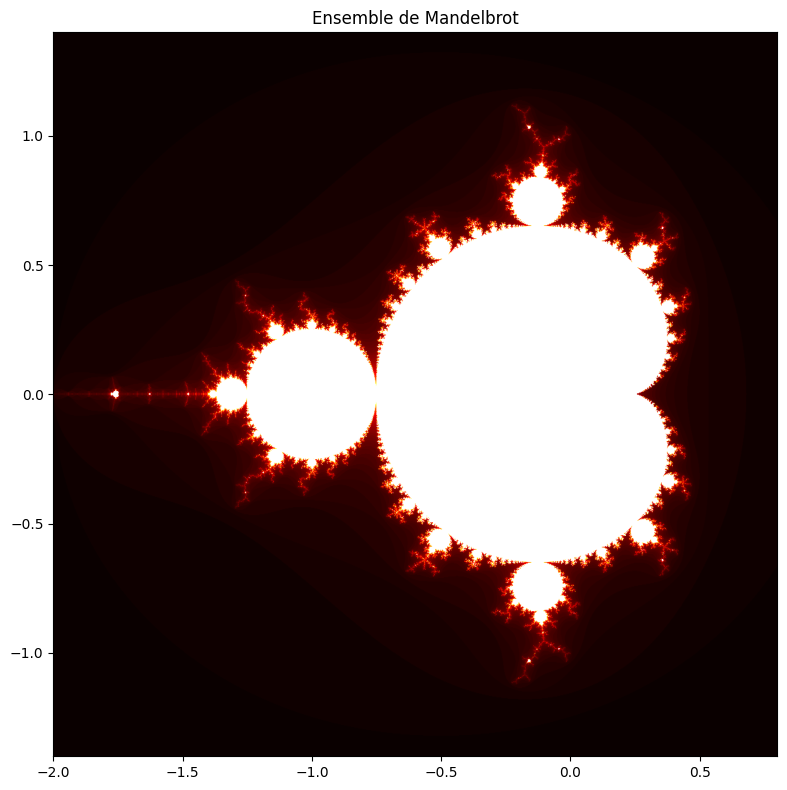

In [190]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(h, w, max_iter):
    y, x = np.ogrid[-1.4:1.4:h*1j, -2:0.8:w*1j]
    c = x + y*1j
    z = c
    divtime = max_iter + np.zeros(z.shape, dtype=int)

    for i in range(max_iter):
        z = z**2 + c
        diverge = z*np.conj(z) > 2**2
        div_now = diverge & (divtime == max_iter)
        divtime[div_now] = i
        z[diverge] = 2

    return divtime

h, w = 1000, 1500
plt.figure(figsize=(12, 8))
plt.imshow(mandelbrot(h, w, 100), cmap='hot', extent=[-2, 0.8, -1.4, 1.4])
plt.title('Ensemble de Mandelbrot')
plt.tight_layout()
plt.savefig('mandelbrot.png', dpi=500)
plt.show()